# Поиск неактивных покупателей для бизнеса

**Проблематика:**  
У бизнеса снижается активность покупателей товаров, новых привлечь сложно и не эффективно.  
Как решение удерживать активность постоянных клиентов с помощью персональных предложений.

**Решение:**
1) Построение модели, которая предскажет **вероятность снижения покупательской активности клиента** в следующие три месяца;  
2) В исследование нужно включить **дополнительные данные финансового департамента о прибыльности клиента**: какой доход каждый покупатель приносил компании за последние три месяца;  
3) Используя данные модели и данные о прибыльности клиентов, нужно выделить **сегменты покупателей** и разработать для них персонализированные предложения.

Целевой признак: **Покупательская активность**

In [2]:
# !pip install "numpy==1.21"

In [4]:
# !pip install "llvmlite==0.38.1"

In [5]:
# !pip install "numba==0.55.1"

In [ ]:
!pip install shap
!pip install "matplotlib==3.5.3"

In [7]:
!pip install phik -s

In [8]:
import warnings
warnings.filterwarnings('ignore', message='.*default behavior of `mode`.*')

In [9]:
import math
import phik

import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st
import matplotlib.pyplot as plt
from phik.report import plot_correlation_matrix

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV)

from sklearn.preprocessing import (OneHotEncoder,
                                   OrdinalEncoder,
                                   StandardScaler,
                                   MinMaxScaler,
                                   RobustScaler,
                                   PolynomialFeatures)

from sklearn.linear_model import (LinearRegression,
                                  LogisticRegression)

from sklearn.metrics import (roc_auc_score, 
                             accuracy_score, 
                             confusion_matrix)

In [11]:
import shap

In [12]:
data_behavior = pd.read_csv('/datasets/market_file.csv')
data_revenue = pd.read_csv('/datasets/market_money.csv') 
data_time = pd.read_csv('/datasets/market_time.csv') 
data_profit = pd.read_csv('/datasets/money.csv', delimiter=';', decimal = ',')

## Обзор данных

In [13]:
data_behavior.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [14]:
data_behavior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [15]:
data_revenue.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [16]:
data_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [17]:
data_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [18]:
data_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [19]:
data_profit.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [20]:
data_profit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


По всем полям тип данных данных приведен в соответствие.

## Предобработка данных

data_behavior
data_revenue
data_time
data_profit

In [21]:
data_behavior.duplicated().sum(), data_revenue.duplicated().sum(), data_time.duplicated().sum(), data_profit.duplicated().sum()

(0, 0, 0, 0)

In [22]:
def show_unique(df):
    '''
    Возвращает словарь где ключом является название
    поля и значением список с уникальными значениями
    '''
    return {i:list(df[i].unique()) for i in df if df[i].dtype == 'object'}

In [23]:
show_unique(data_behavior)

{'Покупательская активность': ['Снизилась', 'Прежний уровень'],
 'Тип сервиса': ['премиум', 'стандартт', 'стандарт'],
 'Разрешить сообщать': ['да', 'нет'],
 'Популярная_категория': ['Товары для детей',
  'Домашний текстиль',
  'Косметика и аксесуары',
  'Техника для красоты и здоровья',
  'Кухонная посуда',
  'Мелкая бытовая техника и электроника']}

In [24]:
data_behavior.loc[data_behavior['Тип сервиса'] == 'стандартт', 'Тип сервиса'] = 'стандарт'

In [25]:
show_unique(data_revenue)

{'Период': ['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц']}

In [26]:
show_unique(data_time)

{'Период': ['текущий_месяц', 'предыдцщий_месяц']}

In [27]:
data_time.loc[data_time['Период'] == 'предыдцщий_месяц', 'Период'] = 'предыдущий_месяц'

In [28]:
show_unique(data_profit)

{}

In [29]:
data_behavior.duplicated().sum(), data_revenue.duplicated().sum(), data_time.duplicated().sum(), data_profit.duplicated().sum()

(0, 0, 0, 0)

Сделали первичную предобработку данных.  
Проверили количество явных дубликатов.  
Удалили не явные дубликаты в полях.  
Посмотрели на категории в полях.

## Исследовательский анализ данных

### Ящики с усами

In [30]:
def show_all_boxplots(data_frame, xlim_min=None, xlim_max=None, xlabel='Значения', ylabel='Переменная'):
    num_cols = [i for i in data_frame if data_frame[i].dtype != 'object']
    num_cols = [col for col in num_cols if col.lower() != "id"]
    
    n = len(num_cols)
    if n == 0:
        print("Нет числовых колонок для построения boxplot.")
        return
    
    ncols = 1
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(17, 2*nrows))
    
    # Гарантируем, что axes будет списком/массивом
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        ax.boxplot(data_frame[col].dropna(), vert=False)
        ax.set_title(f'Ящик с усами {col}', fontsize=15)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True)
        if xlim_min is not None and xlim_max is not None:
            ax.set_xlim(xlim_min, xlim_max)
    
    # Скрываем неиспользованные subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

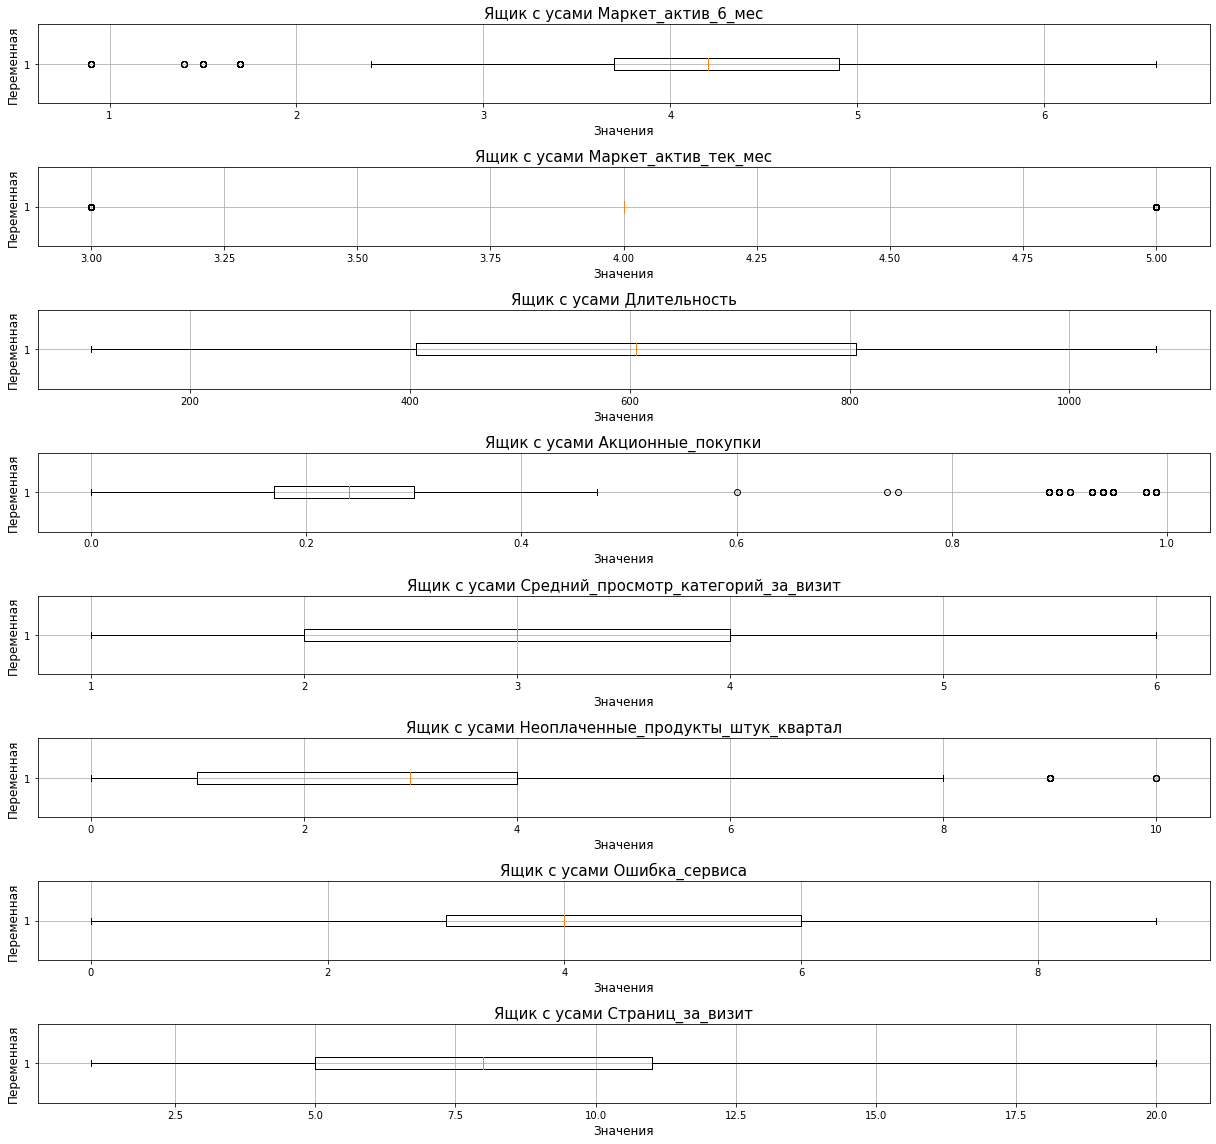

In [31]:
show_all_boxplots(data_behavior)

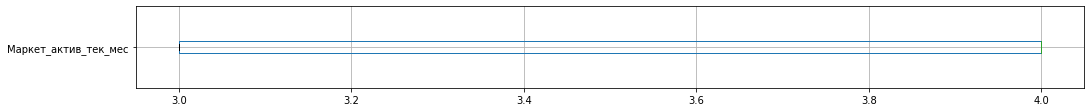

In [32]:
data_behavior[data_behavior['Маркет_актив_тек_мес'] < 4.5].boxplot(column = 'Маркет_актив_тек_мес', vert = False, figsize=(17, 1.5));

In [33]:
data_behavior['Маркет_актив_тек_мес'].unique()

array([5, 4, 3])

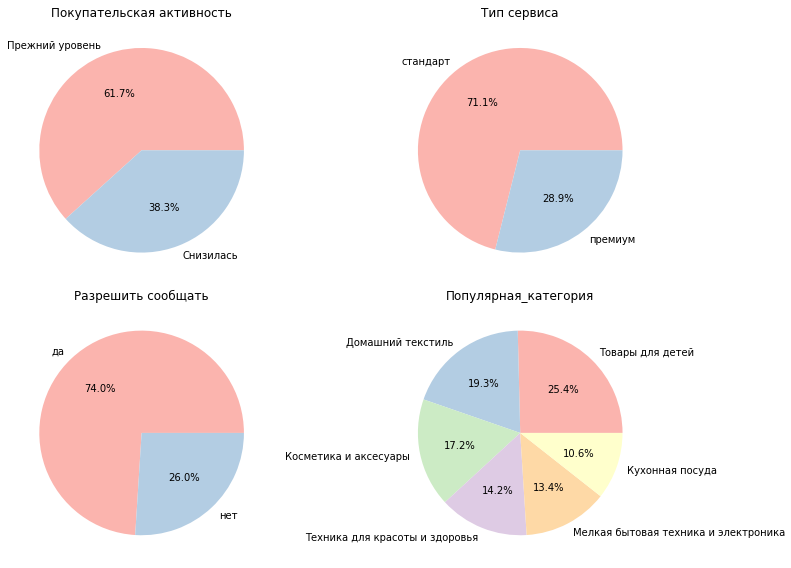

In [34]:
colors = plt.get_cmap('Pastel1').colors

# Получаем список категориальных столбцов
categorical_columns = data_behavior.select_dtypes(include=['object']).columns.tolist()
n_cols = 2  # количество столбцов в сетке
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols  # вычисляем количество строк

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    data = data_behavior[column].value_counts()
    plt.pie(data, labels=data.index, autopct='%1.1f%%', colors=colors)
    plt.title(column)

plt.tight_layout()
plt.show()

По трем категориальным признакам виден дисбаланс классов: "Прежний уровень", "Разрешить сообщать", "Тип сервиса".  
По популярным категориям, распределение более-менее равномерное, за исключением товаров для детей и кухонной посуды.

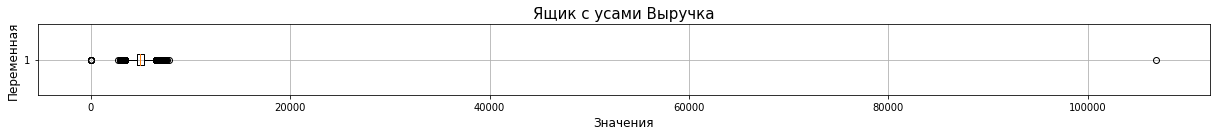

In [35]:
show_all_boxplots(data_revenue)

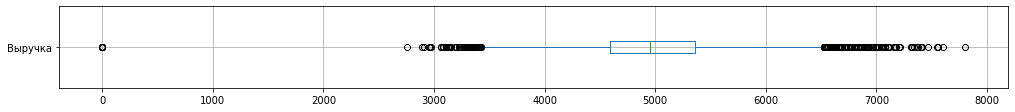

In [36]:
data_revenue[data_revenue['Выручка'] < 100000].boxplot(column = 'Выручка', vert = False, figsize=(17, 1.5));

In [37]:
data_revenue[data_revenue['Выручка'] > 100000]

,id,Период,Выручка
98,215380,текущий_месяц,106862.2


In [38]:
data_revenue[data_revenue['Выручка'] == 0]

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


Выручка больше 100000 выглядит выбросом по сравнению с остальными данными.

In [39]:
data_revenue = data_revenue.query('`Выручка` < 100000 or @pd.isna(`Выручка`)')

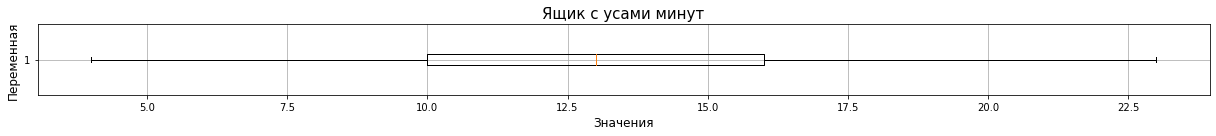

In [40]:
show_all_boxplots(data_time)

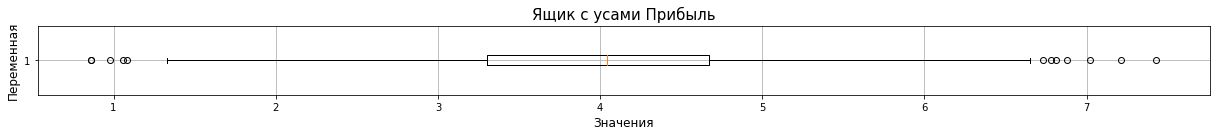

In [41]:
show_all_boxplots(data_profit)

### Гистограммы

In [42]:
def show_all_hists(data_frame, bins=25):
    '''
    На вход принимает переменную в которой хранится исходный датафрейм.
    На выход выдает сетку с несколькими гистограмммами.
    Пропускает поле с названием id и если нет числовых значений в поле.
    '''
    # оставляем только числовые колонки
    num_cols = [i for i in data_frame if data_frame[i].dtype != 'object']
    num_cols = [col for col in num_cols if col.lower() != "id"]  # исключаем id
    
    n = len(num_cols)
    if n == 0:
        print("Нет числовых колонок для построения гистограмм.")
        return
    
    # определим количество строк и столбцов для сетки
    ncols = 1
    nrows = (n + ncols - 1) // ncols  # округляем вверх
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 2*nrows))
    
    # Гарантируем, что axes будет списком/массивом
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        ax.hist(data_frame[col].dropna(), bins=bins)
        ax.set_title(col)
        ax.set_xlabel('Значение', fontsize=12)
        ax.set_ylabel('Кол-во', fontsize=12)
    
    # Скрываем неиспользованные subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

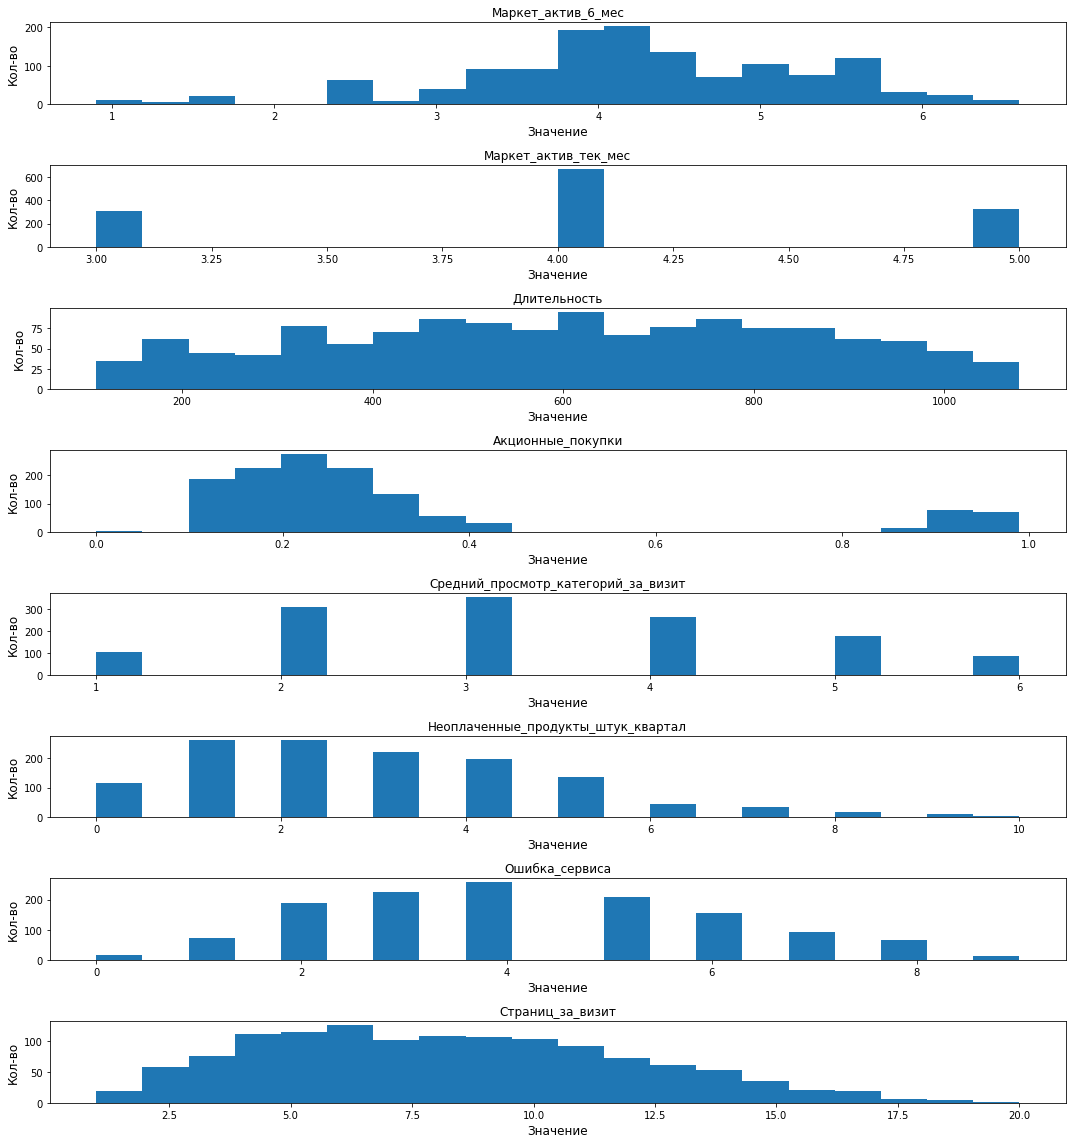

In [43]:
show_all_hists(data_behavior, bins = 20)

In [44]:
data_behavior.describe()

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


- У большинства полей, смотрится распределение близкое к нормальному, но есть такие как "Акционные_покупки" у которых есть разбиение по двум группам данных (некая мультимодальность);
- У поля "Маркет_актив_тек_мес" в общем и целом данные не детально распределены, первый второй и третий квантили приходятся на одно и то же значение, данные распределены по трем группам;
- Данные смотрятся однородно по полям: у всех значения min max mean имеют один числовой порядок;


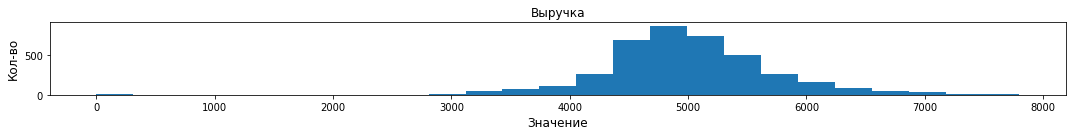

In [45]:
show_all_hists(data_revenue)

In [46]:
data_revenue['Выручка'].describe()

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: Выручка, dtype: float64

- У выручки наблюдается нормальное распределение со сдвигом вправо за счет значений равных нулю.
- Порядок числовых значением у min mean max одинаковый. 

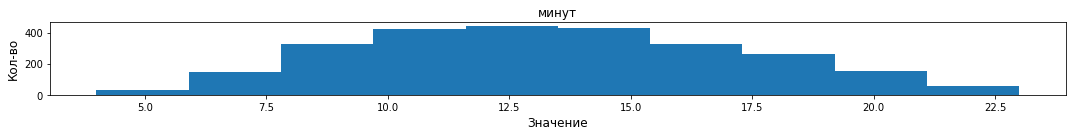

In [47]:
show_all_hists(data_time, bins=10)

In [48]:
data_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

У поля 'минут' смотрится нормальное распределение.

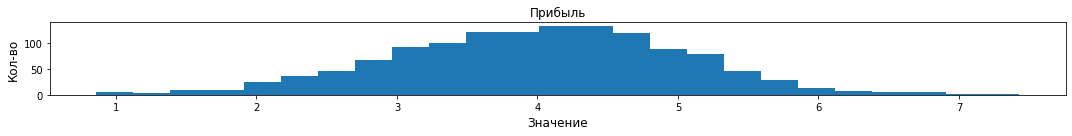

In [49]:
show_all_hists(data_profit)

In [50]:
data_profit['Прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

У прибыли также смотрится нормальное распределение.

Общий вывод таков:
- Не все данные распределены нормально. В связи с этим стоит использовать подход к расчету корреляций через Phik.  
- Однако кроме одного выброса в data_revenue 'Выручка' все данные выглядят реалистично, в дополнении у выручки есть поля со значением 0 предлагается их в дальнейшем убрать при объединении таблиц.  
- Остальные выбросы по полям предлагается не убирать, чтобы не потерять большое количество информации из выгрузок.

## Объединение таблиц

Данные о выручке и времени на сайте находятся в одном столбце для всех периодов.  
В итоговой таблице должен быть отдельный столбец для каждого периода.
Необходимо также добавить новые названия полям, иначе возникнет путаница

In [51]:
data_revenue_p = data_revenue.pivot(index='id', columns='Период', values='Выручка').reset_index()
data_revenue_p.columns = ['id', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц','выручка_текущий_месяц']
data_revenue_p.head()

,id,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215348,0.0,0.0,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5


In [52]:
data_time_p = data_time.pivot(index='id', columns='Период', values='минут').reset_index()
data_time_p.columns = ['id', 'минуты_предыдущий_месяц', 'минуты_текущий_месяц']
data_time_p.head()

,id,минуты_предыдущий_месяц,минуты_текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11


In [53]:
data_behavior.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [54]:
data_all = pd.merge(data_time_p, data_revenue_p,on = 'id', how = 'left')
data_all = pd.merge(data_all, data_behavior, on = 'id', how = 'left')
data_all.head()

,id,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,13,14,0.0,0.0,3293.1,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,12,10,5216.0,4472.0,4971.6,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,8,13,5457.5,4826.0,5058.4,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,11,13,6158.0,4793.0,6610.4,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,8,11,5807.5,4594.0,5872.5,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [55]:
data_all.isna().sum()

id                                     0
минуты_предыдущий_месяц                0
минуты_текущий_месяц                   0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  1
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [56]:
data_all = data_all.dropna(subset=['выручка_текущий_месяц'])

In [57]:
data_all.loc[data_all['выручка_препредыдущий_месяц'] == 0]

,id,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,13,14,0.0,0.0,3293.1,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5
9,215357,12,6,0.0,0.0,5986.3,Снизилась,стандарт,да,3.9,5,154,0.0,Техника для красоты и здоровья,3,3,9,5
11,215359,13,11,0.0,0.0,4735.0,Снизилась,стандарт,да,4.6,5,110,0.0,Домашний текстиль,4,2,4,2


Три пользователя с нулевой выручком. Избавимся от них.

In [58]:
data_all = data_all[data_all['выручка_препредыдущий_месяц'] != 0]
data_all.loc[data_all['выручка_препредыдущий_месяц'] == 0]

,id,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит


In [59]:
[i for i in data_all if data_all[i].dtype != 'object']

['id',
 'минуты_предыдущий_месяц',
 'минуты_текущий_месяц',
 'выручка_предыдущий_месяц',
 'выручка_препредыдущий_месяц',
 'выручка_текущий_месяц',
 'Маркет_актив_6_мес',
 'Маркет_актив_тек_мес',
 'Длительность',
 'Акционные_покупки',
 'Средний_просмотр_категорий_за_визит',
 'Неоплаченные_продукты_штук_квартал',
 'Ошибка_сервиса',
 'Страниц_за_визит']

## Корреляционный анализ

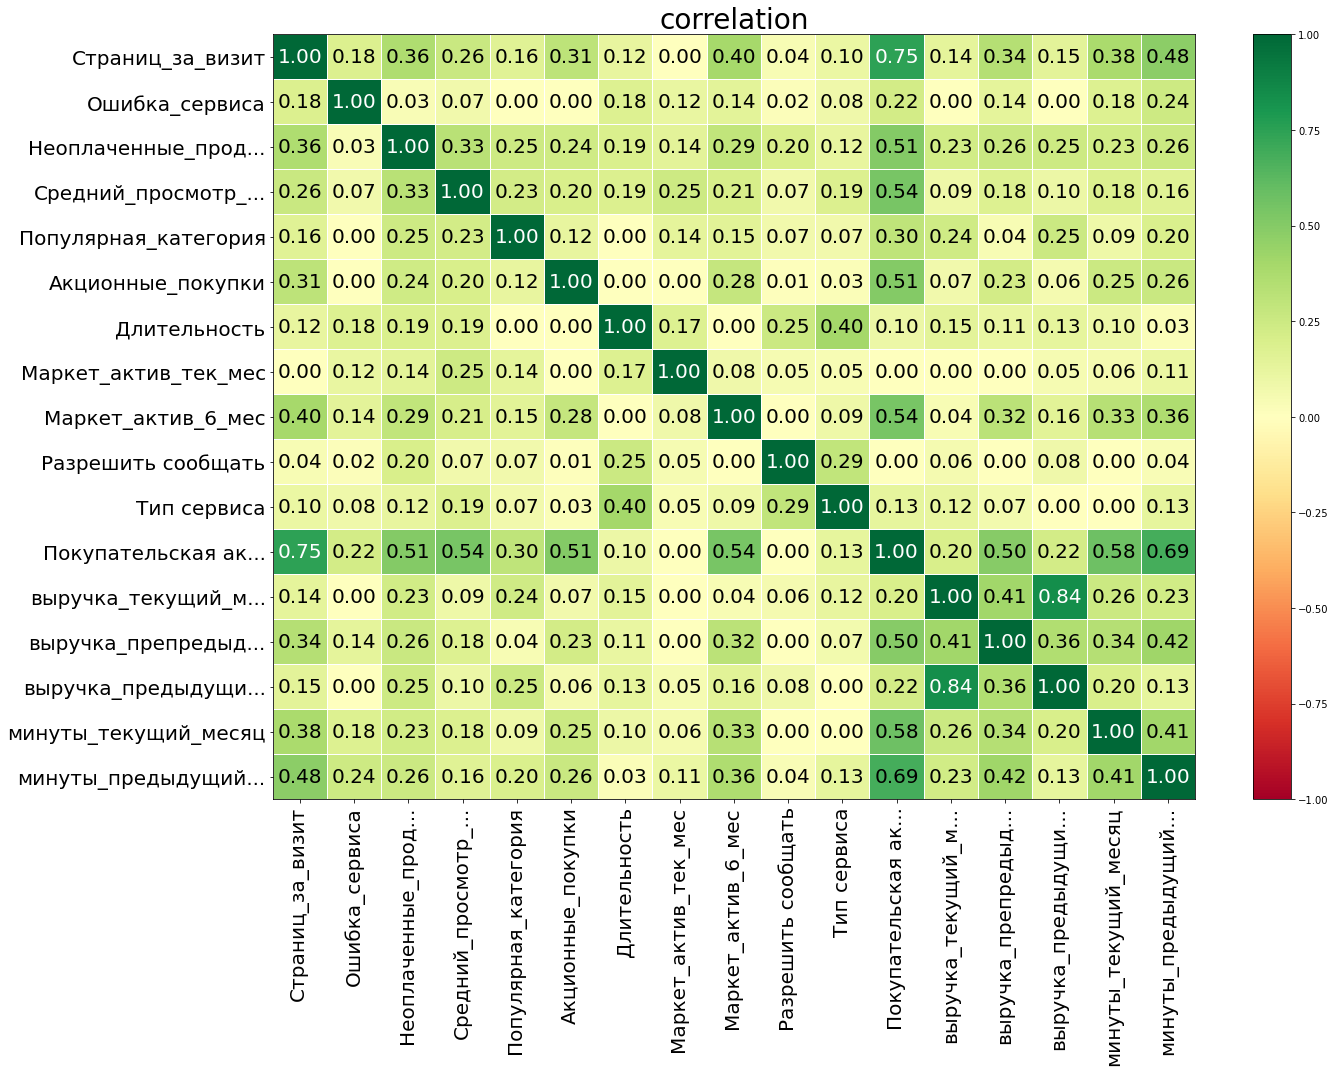

In [60]:
phik_m = data_all.drop(['id'], axis=1).phik_matrix(interval_cols=[i for i in data_all if data_all[i].dtype != 'object'])

stacked_corr = phik_m.stack()

no_self_corr = stacked_corr[stacked_corr.index.get_level_values(0) != stacked_corr.index.get_level_values(1)]

unique_pairs = no_self_corr[
    no_self_corr.index.get_level_values(0) < no_self_corr.index.get_level_values(1)
]

correlation_threshold = 0.5

high_corr = unique_pairs[abs(unique_pairs) > correlation_threshold]

sorted_high_corr = high_corr.sort_values(ascending=False)

plot_correlation_matrix(phik_m.values, x_labels = phik_m.columns, y_labels = phik_m.index, fontsize_factor = 2, figsize = (20,15))

По шкале Чеддока заметной связью являются значения корреляции от 0.5, выведем корреляции полей между друг другом:

In [61]:
print(sorted_high_corr)

выручка_предыдущий_месяц            выручка_текущий_месяц                  0.836281
Покупательская активность           Страниц_за_визит                       0.749888
                                    минуты_предыдущий_месяц                0.685138
                                    минуты_текущий_месяц                   0.576770
Маркет_актив_6_мес                  Покупательская активность              0.544831
Покупательская активность           Средний_просмотр_категорий_за_визит    0.539607
Акционные_покупки                   Покупательская активность              0.506276
Неоплаченные_продукты_штук_квартал  Покупательская активность              0.505655
dtype: float64


In [62]:
parameter_names = [i for i in data_all if data_all[i].dtype != 'object']
parameter_names

['id',
 'минуты_предыдущий_месяц',
 'минуты_текущий_месяц',
 'выручка_предыдущий_месяц',
 'выручка_препредыдущий_месяц',
 'выручка_текущий_месяц',
 'Маркет_актив_6_мес',
 'Маркет_актив_тек_мес',
 'Длительность',
 'Акционные_покупки',
 'Средний_просмотр_категорий_за_визит',
 'Неоплаченные_продукты_штук_квартал',
 'Ошибка_сервиса',
 'Страниц_за_визит']

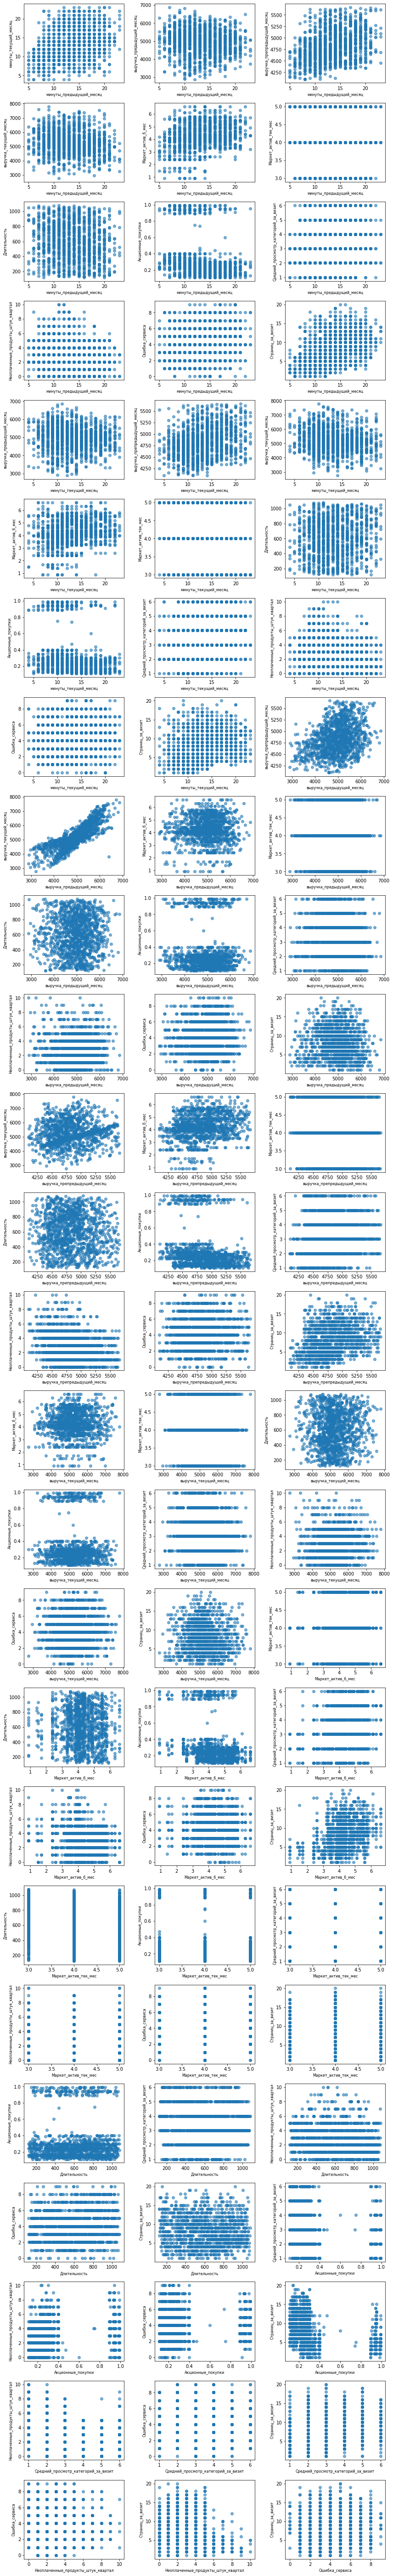

In [63]:
data_all_for_chart = data_all.drop(['id'], axis=1)
numeric_cols = data_all_for_chart.select_dtypes(include='number').columns
pairs = list(itertools.combinations(numeric_cols, 2))  # уникальные пары

ncols = 3
nrows = math.ceil(len(pairs) / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 3))
axs = axs.flatten()

for i, (x, y) in enumerate(pairs):
    axs[i].scatter(data_all_for_chart[x], data_all_for_chart[y], alpha=0.6)
    axs[i].set_xlabel(x, fontsize=8)
    axs[i].set_ylabel(y, fontsize=8)

# скрываем пустые оси
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Мультиколиниарности по количественным признакам отсутсвует, при этом есть некоторая линейная зависимость между выручкой за прошлый период и текущий.

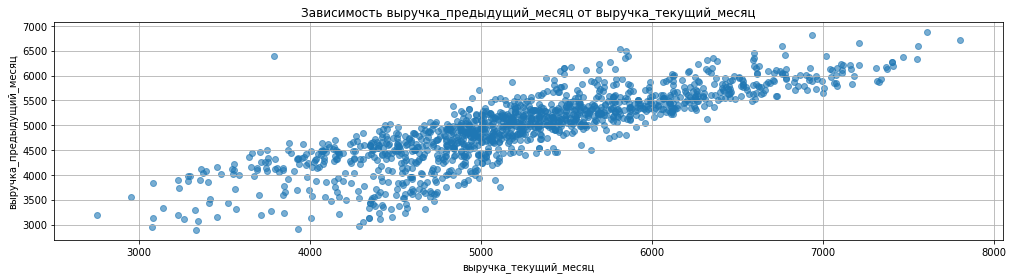

In [64]:
plt.figure(figsize=(17, 4))
plt.scatter(data_all['выручка_текущий_месяц'], data_all['выручка_предыдущий_месяц'], alpha=0.6)
plt.xlabel('выручка_текущий_месяц')
plt.ylabel('выручка_предыдущий_месяц')
plt.title("Зависимость выручка_предыдущий_месяц от выручка_текущий_месяц")
plt.grid(True)
plt.show()

Каких-то сильных линейных зависимостей между входными признаками не обнаружено, также по таблице корреляций Phik, нет сильных корреляций ~0.9. Мультиколлинеарность отсутствует.  

## Использование пайплайнов

In [65]:
num_columns = [i for i in data_all if data_all[i].dtype != 'object']
cat_columns = [i for i in data_all if data_all[i].dtype == 'object']

In [66]:
num_columns

['id',
 'минуты_предыдущий_месяц',
 'минуты_текущий_месяц',
 'выручка_предыдущий_месяц',
 'выручка_препредыдущий_месяц',
 'выручка_текущий_месяц',
 'Маркет_актив_6_мес',
 'Маркет_актив_тек_мес',
 'Длительность',
 'Акционные_покупки',
 'Средний_просмотр_категорий_за_визит',
 'Неоплаченные_продукты_штук_квартал',
 'Ошибка_сервиса',
 'Страниц_за_визит']

In [67]:
show_unique(data_all)

{'Покупательская активность': ['Снизилась', 'Прежний уровень'],
 'Тип сервиса': ['премиум', 'стандарт'],
 'Разрешить сообщать': ['да', 'нет'],
 'Популярная_категория': ['Товары для детей',
  'Домашний текстиль',
  'Косметика и аксесуары',
  'Кухонная посуда',
  'Техника для красоты и здоровья',
  'Мелкая бытовая техника и электроника']}

- У поля 'Популярная категория' значения категорий равноправны и их нельзя упорядочить логически.  
- У поля 'Тип сервиса' есть логическая упорядочность: сначала стаднартный, потом премиум сервис.  
- У целевой переменной 'Покупательская активность': также есть логическая упорядочность либо прежний уровень, либо уровень ниже (снизилась).   

Нужно будет это учитывать при подготовке признаков для модели.

In [68]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    data_all.drop(['Покупательская активность'],axis=1),
    data_all['Покупательская активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = data_all['Покупательская активность'])

ohe_columns = ['Популярная_категория', 'Разрешить сообщать']
ord_columns = ['Тип сервиса']

X_test_id = X_test.copy()
X_train_id = X_train.copy()

X_test = X_test.drop('id', axis = 1)
X_train = X_train.drop('id', axis = 1)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [69]:
num_columns.remove('выручка_текущий_месяц')
num_columns.remove('выручка_предыдущий_месяц')
num_columns.remove('выручка_препредыдущий_месяц')
num_columns.remove('id')
num_columns

['минуты_предыдущий_месяц',
 'минуты_текущий_месяц',
 'Маркет_актив_6_мес',
 'Маркет_актив_тек_мес',
 'Длительность',
 'Акционные_покупки',
 'Средний_просмотр_категорий_за_визит',
 'Неоплаченные_продукты_штук_квартал',
 'Ошибка_сервиса',
 'Страниц_за_визит']

In [70]:
# ПАЙПЛАЙН для простых категориальных признаков
ohe_pipe = Pipeline([
    (
        'simpleImputer_ohe', 
        SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    ),
    (    
        'ohe', 
        OneHotEncoder(handle_unknown='ignore', sparse=False)  # УБРАЛ drop='first'
    )
])

In [71]:
# ПАЙПЛАЙН для логических категориальных признаков
ord_pipe = Pipeline([
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
       (
            'simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
])

In [72]:
# ПАЙПЛАЙН общий для всех признаков
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)   
    ], 
    remainder =  'passthrough'
)
print(data_preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False))]),
                                 ['Популярная_категория',
                                  'Разрешить сообщать']),
                                ('ord',
                                 Pipeline(steps=[('simpleImputer_before_ord',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  Or...
                                                 ('simpleImputer_after_ord',
          

In [73]:
pipe_final= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [74]:
param_grid = [
    # Дерево решений
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2,5),
        'models__max_features': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # K ближайших соседей
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели Логистическая регрессия
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE)],
        'models__C': range(1,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE, probability = True)],
        'models__kernel' : ('linear', 'rbf', 'sigmoid'),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [75]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

1) У нас есть дисбаланс классов как входных признаков так и целового.  
2) Необходима не только точность, а способность различать низко-активных пользователей от высоко активных, ибо оба класса пользователей для нас важны, в отличии от precision/recall где мы фокус держим на одном из классов.

Выбираем ROC AUC как метрику, потому что она оптимально оценивает способность модели ранжировать пользователей по активности, устойчива к дисбалансу классов и позволяет гибко выбирать порог классификации под изменяющиеся бизнес-условия.


In [76]:
randomized_search.fit(X_train, y_train)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse=False))]),
                                                                               ['Популярная_категория',
             

In [77]:
print('\nЛучшая модель и её параметры:\n\n', randomized_search.best_estimator_)


Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Популярная_категория',
                                                   'Разрешить сообщать']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                       

In [78]:
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)

In [79]:
result = pd.DataFrame(randomized_search.cv_results_)
result[
    ['rank_test_score', 'mean_test_score','params']
].sort_values('mean_test_score').tail()

,rank_test_score,mean_test_score,params
7,5,0.754093,"{'preprocessor__num': MinMaxScaler(), 'models__n_neighbors': 3, 'models': KNeighborsClassifier()}"
3,3,0.779907,"{'preprocessor__num': MinMaxScaler(), 'models__max_features': 3, 'models__max_depth': 3, 'models': DecisionTreeClassifier(random_state=42)}"
9,3,0.779907,"{'preprocessor__num': StandardScaler(), 'models__max_features': 3, 'models__max_depth': 3, 'models': DecisionTreeClassifier(random_state=42)}"
0,2,0.796826,"{'preprocessor__num': StandardScaler(), 'models__max_features': 2, 'models__max_depth': 2, 'models': DecisionTreeClassifier(random_state=42)}"
8,1,0.894350,"{'preprocessor__num': StandardScaler(), 'models__C': 4, 'models': LogisticRegression(C=4, random_state=42)}"


Лучшей моделью стала логистическая регрессия со слабой регулизацией.

In [80]:
# Посчитаем тестовый прогноз
y_test_pred = randomized_search.predict(X_test)

probabilities = randomized_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
y_test_roc = y_test.map(lambda x: 1 if x == 'Снизилась' else 0).astype('int64')

In [81]:
print(f'Метрика Accuracy на тесте: {accuracy_score(y_test, y_test_pred)}')
print(f'Метрика ROC-AUC на тесте: {roc_auc_score(y_test_roc, probabilities_one)}')

Метрика Accuracy на тесте: 0.8888888888888888
Метрика ROC-AUC на тесте: 0.9123083768151113


In [82]:
classes = np.unique(y_test)

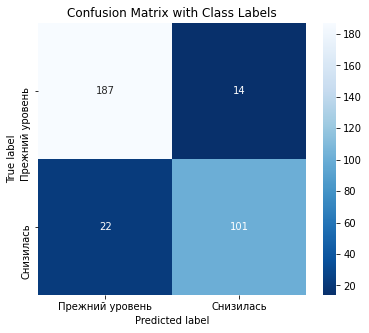

In [83]:
cm = confusion_matrix(y_test, y_test_pred, labels=classes)

# Визуализация с явной подписью классов
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r',
            xticklabels=classes, yticklabels=classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with Class Labels')
plt.show()

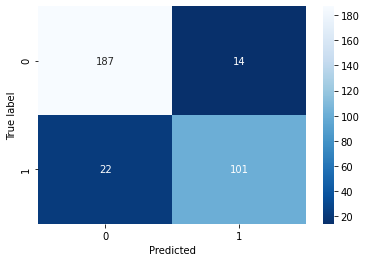

In [84]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted'); 

В общем и целом - ошибок не так много:  
    Ошибок первого рода у нас около 11 шт., что является важным показателем для нашей задачи,  
    ведь возможно бизнесс в дальнейшем будет тратить деньги на различные акции для низкоактивных пользователей, но при этом ошибки второго рода упущенная возможность в доп. прибыли, но их также не так много ~ 30 шт.  
    Ошибки достаточно сбалансированы и не отличаются на порядки. В этом как раз и помогла метрика ROC-AUC.

## Анализ важности признаков

Количество признаков: 22
Размер transformed данных: 22


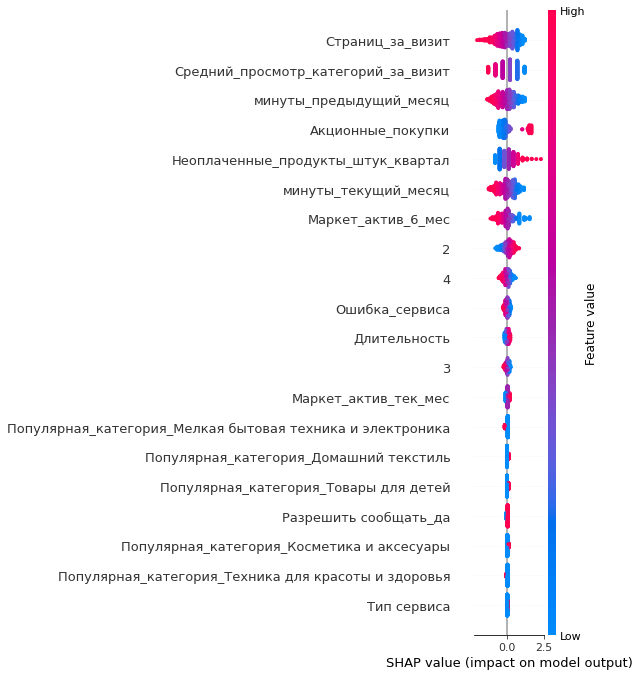

In [85]:
best_model = randomized_search.best_estimator_

X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
classifier_step = best_model.named_steps['models']
if isinstance(classifier_step, DecisionTreeClassifier) or hasattr(classifier_step, 'predict_proba'):
    explainer = shap.Explainer(classifier_step, X_test_transformed)
else:
    explainer = shap.KernelExplainer(classifier_step.predict, X_test_transformed)

shap_values = explainer(X_test_transformed)

# СОЗДАЕМ НОРМАЛЬНЫЕ ИМЕНА ПРИЗНАКОВ
preprocessor = best_model.named_steps['preprocessor']
feature_names = []

for name, transformer, columns in preprocessor.transformers_:
    if name == 'ohe':
        # Для OneHotEncoder - создаем имена категорий
        ohe_transformer = transformer.named_steps['ohe']
        for i, col in enumerate(columns):
            categories = ohe_transformer.categories_[i]
            for category in categories:
                feature_names.append(f"{col}_{category}")
    elif name == 'ord':
        # Для OrdinalEncoder - оставляем исходные имена
        feature_names.extend(columns)
    elif name == 'num':
        # Для числовых признаков
        feature_names.extend(columns)
    elif name == 'remainder':
        # Для остальных признаков
        feature_names.extend(columns)

# Проверяем, что количество имен совпадает
print(f"Количество признаков: {len(feature_names)}")
print(f"Размер transformed данных: {X_test_transformed.shape[1]}")

# Визуализация с нормальными именами
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=20)

Выводы

Практически не влияющие признаки
- Тип сервиса (премиум/стандарт)  
- Количество маркетинговых коммуникаций в текущем месяце  
- Популярная категория «Кухонная посуда»  
- Разрешить сообщать "нет"

Наибольшее влияние
- Страниц за визит
- Средний просмотр категории за визит 

Рекомендации для маркетинга
- Увеличивать количество просмотренных категорий и страниц персонализированно для пользоваталей, путем рекомендательной системы товаров;
- Информировать о акциях и создавать новые интересные предложения также на основе рекомендательных систем;  
- Фокус на любителях электроники и мелкой бытовой техники - можно сделать этот признак более важным;


## Сегментация покупателей

In [86]:
X_test_id['Forecasts'] = y_test_pred
X_test_id['Probabilities'] = probabilities_one

In [87]:
X_test_id['Forecasts'] = X_test_id['Forecasts'].map(lambda x: 1 if x == 'Снизилась' else 0).astype('int64')
X_test_id = pd.merge(X_test_id, data_profit, on = 'id', how = 'left')

X_test_id.sort_index()

,id,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Forecasts,Probabilities,Прибыль
0,216161,16,17,3973.0,4912.0,3289.2,стандарт,да,4.1,4,606,0.15,Техника для красоты и здоровья,6,1,4,12,0,0.011379,4.69
1,215654,11,9,3548.0,4656.0,4170.7,премиум,нет,1.4,4,684,0.94,Товары для детей,3,6,1,6,1,0.990709,2.75
2,216307,20,11,5444.0,4565.0,6335.8,премиум,да,3.3,4,488,0.13,Домашний текстиль,4,2,8,10,0,0.077853,3.16
3,215501,9,9,6604.0,4993.0,6758.7,премиум,да,3.5,3,1057,0.35,Домашний текстиль,4,3,5,6,1,0.815715,3.74
4,215934,15,18,5090.0,4451.0,5773.8,стандарт,нет,5.5,4,147,0.99,Мелкая бытовая техника и электроника,1,2,3,7,1,0.583291,4.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,215429,11,10,3662.0,4488.0,4158.6,премиум,нет,0.9,4,690,0.24,Домашний текстиль,2,5,7,4,1,0.963230,3.71
320,216233,15,17,4325.0,4553.0,4257.4,премиум,да,3.9,4,1048,0.21,Техника для красоты и здоровья,3,0,6,14,0,0.042560,4.62
321,215716,13,14,3067.0,4165.0,3343.9,стандарт,да,2.4,4,952,0.30,Техника для красоты и здоровья,3,5,2,3,1,0.875164,4.07
322,216141,14,10,5660.5,4885.0,6462.6,стандарт,нет,4.0,4,748,0.28,Косметика и аксесуары,4,0,4,9,0,0.158409,1.97


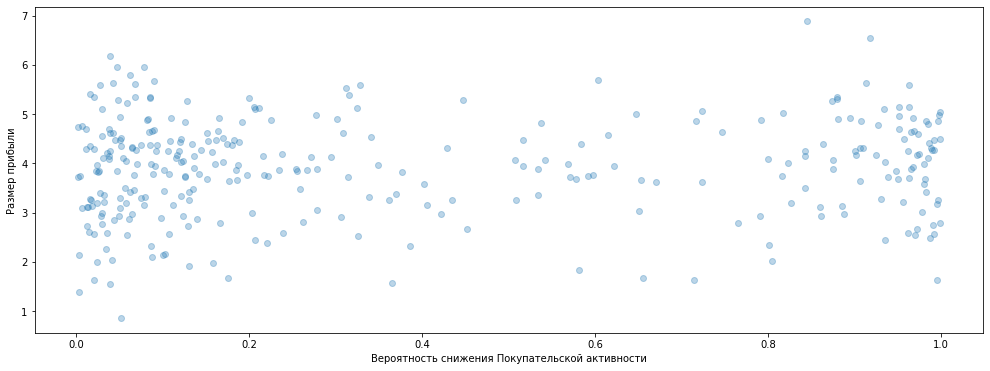

In [89]:
plt.figure(figsize=(17, 6))
plt.scatter(X_test_id['Probabilities'], X_test_id['Прибыль'], alpha=0.3)
plt.xlabel('Вероятность снижения Покупательской активности')
plt.ylabel('Размер прибыли')
plt.show()

Какое-то неоднозначное распределение, размер прибыли может быть как низким и высоким при нулевой вероятности, так и при высокой - границы графика по абсциссе. 
Предлагается взять сегмент в с высокой вероятностью снижения активности и выосокой прибылью как целевую аудиторию с которой нужно будет работать.

In [91]:
data_segment = X_test_id[(X_test_id['Прибыль'] > 3.5) & (X_test_id['Probabilities'] > 0.75)]
data_segment.head()

,id,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Forecasts,Probabilities,Прибыль
3,215501,9,9,6604.0,4993.0,6758.7,премиум,да,3.5,3,1057,0.35,Домашний текстиль,4,3,5,6,1,0.815715,3.74
12,215375,8,9,5253.5,4715.0,5633.1,премиум,да,3.0,4,558,0.89,Товары для детей,3,3,7,4,1,0.974971,4.18
18,215452,11,10,4045.0,4963.0,4206.2,стандарт,да,3.8,4,756,0.90,Товары для детей,2,3,6,4,1,0.957100,4.50
21,215484,5,7,5059.0,4267.0,5018.7,премиум,нет,2.9,5,448,0.23,Товары для детей,4,2,6,3,1,0.913029,5.64
22,215671,7,8,5379.5,4670.0,6034.7,премиум,да,4.0,4,820,0.22,Косметика и аксесуары,1,4,8,6,1,0.938238,3.73


In [92]:
data_segment.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 3 to 323
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   62 non-null     int64  
 1   минуты_предыдущий_месяц              62 non-null     int64  
 2   минуты_текущий_месяц                 62 non-null     int64  
 3   выручка_предыдущий_месяц             62 non-null     float64
 4   выручка_препредыдущий_месяц          62 non-null     float64
 5   выручка_текущий_месяц                62 non-null     float64
 6   Тип сервиса                          62 non-null     object 
 7   Разрешить сообщать                   62 non-null     object 
 8   Маркет_актив_6_мес                   62 non-null     float64
 9   Маркет_актив_тек_мес                 62 non-null     int64  
 10  Длительность                         62 non-null     int64  
 11  Акционные_покупки                

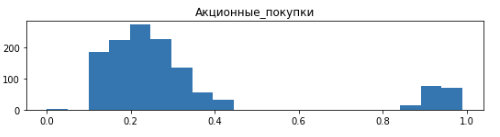

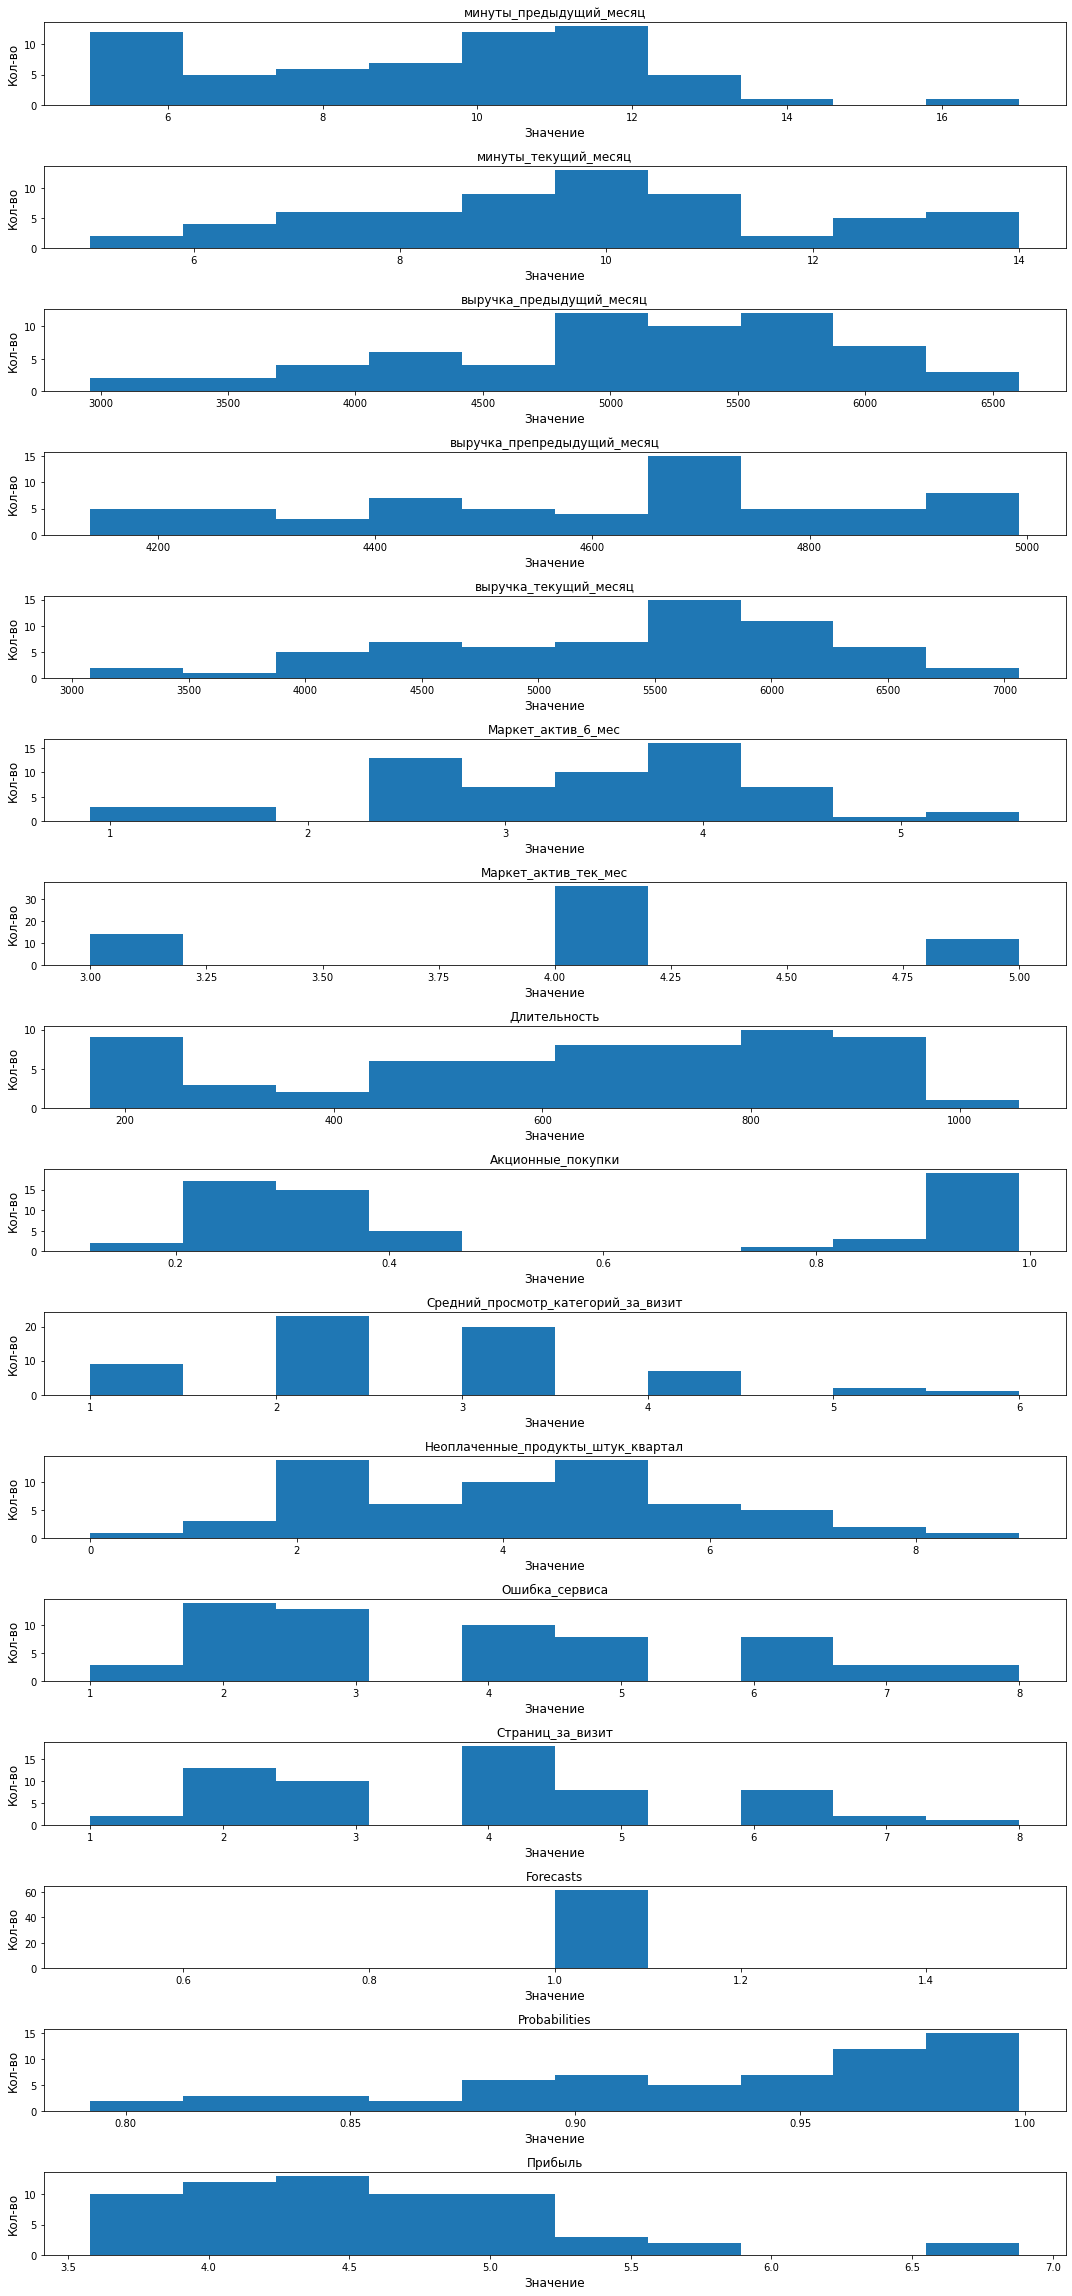

In [93]:
show_all_hists(data_segment, bins = 10)

Распределения в большинстве своем имеют вид не близкого к нормальному.

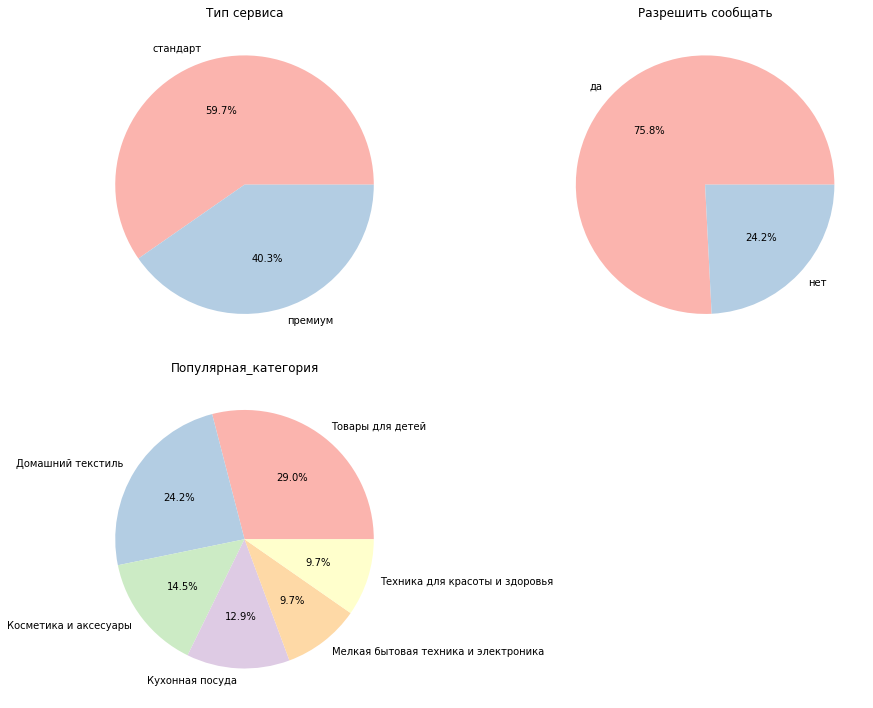

In [94]:
colors = plt.get_cmap('Pastel1').colors

# Получаем список категориальных столбцов
categorical_columns = data_segment.select_dtypes(include=['object']).columns.tolist()
n_cols = 2  # количество столбцов в сетке
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols  # вычисляем количество строк

plt.figure(figsize=(n_cols*6, n_rows*5))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    data = data_segment[column].value_counts()
    plt.pie(data, labels=data.index, autopct='%1.1f%%', colors=colors)
    plt.title(column)

plt.tight_layout()
plt.show()

Проаназировав гистограммы и круговые диаграммы с соотношением:  
- Количество акционных покупок ниже чем у общей выборки и ниже распределение по корзинам;  
- Две больших категорий товаров: для детей и косметика с аксессуарами;  
- Тип стандартного сервиса привалирует;  
- Трети покупателям не приходит дополнительная информаци;

## Общий вывод

Опишите задачу;
опишите исходные данные и проведённую предобработку;
напишите, что вы сделали для поиска лучшей модели;
укажите лучшую модель;
добавьте выводы и дополнительные предложения для выбранного сегмента покупателей.

Было дано несколько исходных датафреймов по покупательской активности и сопутствующим признакам.
Была выполнена предобработка данных, данные в большинстве своем были распределены нормально, выбросов почти не наблюдалось.
Несколько признаков связанные с выручкой, были определены как возможные к утечке данных для модели.

Был построен пайплайн с помощью, которого по лучшим значениям ROC-AUC была выбрана логистическая регрессия  «Чем проще решение, тем мудрее его поиск».

Для выбранного сегмента покупателей предлагается комплексный подход:  
    **1** Попробовать "бить" в акционные покупки и увеличить их распределение по корзинам в гистограмме;  
    **1.1** Это можно сделать расширив акции на другие товары, которые находятся в меньшестве: мелкоая бытовая техника, техника для красоты;  
    **2** Запросить еще раз возможность рассылки персональных предложений;  
    **3** Дать пробные временные доступы к премиум сервису;